# Exploratory Data Analysis

This notebook performs **Exploratory Data Analysis (EDA)** for the MEPS Panel 27 dataset.  
It sets up the working environment (imports and project paths), loads the prepared data, and then provides a high-level understanding of the dataset through:

- Basic dataset checks (shape, data types, and missing values)
- Summary statistics for key variables (especially costs and utilization)
- Visual exploration of distributions (e.g., expenditures, counts) and transformations (e.g., log cost)
- Comparison of outcomes across demographic, socioeconomic, and health subgroups
- Quick inspection of relationships between predictors and targets to guide feature engineering and modeling

All plots and summary outputs are saved into the project `results/` folder for later reporting.


In [3]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
print("CWD:", os.getcwd()) 

CWD: /Users/wenxi/Desktop/TFM_25/notebooks


## 1. Load raw data

In [4]:
import os
import sys
from pathlib import Path


PROJECT_ROOT = Path.cwd().parent   
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

from src.data_io import load_raw_meps
from src.config import RAW_DATA_PATH

print("RAW_DATA_PATH from config:", RAW_DATA_PATH)

df_raw = load_raw_meps()   
print("Raw shape:", df_raw.shape)
df_raw.head()


PROJECT_ROOT: /Users/wenxi/Desktop/TFM_25
RAW_DATA_PATH from config: /Users/wenxi/Desktop/TFM_25/data/h252.xlsx
Raw shape: (8292, 2648)


,DUID,PID,DUPERSID,PANEL,YEARIND,SAQRDS24,ALL5RDS,DIED,INST,MILITARY,...,RXOSRY1,RXOSRY2,RXPTRY1,RXPTRY2,RXOTHY1,RXOTHY2,VARPSU,VARSTR,LONGWT,LSAQWT
0,2790002,101,2790002101,27,1,1,1,0,0,0,...,0,0,477,82,0,0,1,2019,28764.957562,38800.049850
1,2790002,102,2790002102,27,1,0,1,0,0,0,...,0,0,0,0,0,0,1,2019,73143.190424,0.000000
2,2790004,101,2790004101,27,1,0,1,0,0,0,...,0,0,0,0,0,0,1,2084,52401.895364,71295.789233
3,2790006,101,2790006101,27,1,1,1,0,0,0,...,0,0,0,0,0,0,1,2113,26781.859335,27214.872872
4,2790006,102,2790006102,27,1,0,1,0,0,0,...,0,0,0,0,0,0,1,2113,42444.547450,0.000000


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8292 entries, 0 to 8291
Columns: 2648 entries, DUID to LSAQWT
dtypes: float64(25), int64(2603), object(20)
memory usage: 167.5+ MB


In [6]:
df_raw.columns[:50]

Index(['DUID', 'PID', 'DUPERSID', 'PANEL', 'YEARIND', 'SAQRDS24', 'ALL5RDS',
       'DIED', 'INST', 'MILITARY', 'ENTRSRVY', 'LEFTUS', 'OTHER', 'DATAYEARY1',
       'DATAYEARY2', 'FAMID1', 'FAMID2', 'FAMID3', 'FAMID4', 'FAMID5',
       'FAMIDY1', 'FAMIDY2', 'FAMIDYR1', 'FAMIDYR2', 'CPSFAMY1', 'CPSFAMY2',
       'FCSZY1', 'FCSZY2', 'FCRPY1', 'FCRPY2', 'RULETR1', 'RULETR2', 'RULETR3',
       'RULETR4', 'RULETR5', 'RULETRY1', 'RULETRY2', 'RUSIZE1', 'RUSIZE2',
       'RUSIZE3', 'RUSIZE4', 'RUSIZE5', 'RUSIZEY1', 'RUSIZEY2', 'RUCLAS1',
       'RUCLAS2', 'RUCLAS3', 'RUCLAS4', 'RUCLAS5', 'RUCLASY1'],
      dtype='object')

## 2. Variable selection approach (column control)

Because the raw MEPS Panel 27 file contains **2,600+ variables**, this project uses a **whitelist (keep-list)** strategy to control dimensionality and keep the workflow reproducible:

- First, we define a set of **core variable modules** aligned with the research goals (IDs/weights, targets, demographics, insurance/economics, health/chronic conditions, Year-1 utilization/cost summaries).
- Then we keep **only those columns** and drop everything else inside the notebook, while the **raw dataset remains unchanged**.

Concretely, the function `select_core_columns()` in `preprocessing.py` implements this whitelist.  
If we want to add more variables later, we simply **append their names to the whitelist** in `preprocessing.py` and rerun the pipeline.


### Checking variable name patterns (Y1 vs Y2) and confirming outcome columns

In this section, we **scan the raw dataset columns** to understand MEPS naming conventions and to **confirm the exact variables needed for our targets**.

- **Year-specific columns**



In [7]:
cols_y1 = [c for c in df_raw.columns if c.endswith("Y1")]
cols_y2 = [c for c in df_raw.columns if c.endswith("Y2")]

len(cols_y1), len(cols_y2)
cols_y1[:30]


['DATAYEARY1',
 'FAMIDY1',
 'CPSFAMY1',
 'FCSZY1',
 'FCRPY1',
 'RULETRY1',
 'RUSIZEY1',
 'RUCLASY1',
 'FAMSZEY1',
 'FMRSY1',
 'FAMSY1',
 'FAMRFPY1',
 'REGIONY1',
 'REFPRSY1',
 'RESPY1',
 'PROXY1',
 'PROXYY1',
 'BEGRFY1',
 'ENDRFY1',
 'ENDRFMY1',
 'ENDRFYY1',
 'KEYNESY1',
 'INSCOPY1',
 'INSCY1',
 'ELGRNDY1',
 'AGELSTY1',
 'SPOUIDY1',
 'SPOUINY1',
 'ACTDTY1',
 'HIBPDXY1']

- Total expenditure targets

In [8]:
[c for c in df_raw.columns if "TOT" in c and "EXP" in c]



['TOTEXPY1', 'TOTEXPY2']

This quickly verifies that the dataset contains the two core cost outcomes:

- TOTEXPY1 (Year 1 total expenditure)

- TOTEXPY2 (Year 2 total expenditure; main regression outcome)

- Emergency department (ED) variables

In [9]:
[c for c in df_raw.columns if "ER" in c and "TOT" in c]

['ERTOTY1', 'ERTOTY2', 'ERTOTHY1', 'ERTOTHY2']

This returns:

- ERTOTY1, ERTOTY2: ED visit counts (used for defining ANY_ED_Y2 = 1 if ERTOTY2 > 0)

- ERTOTHY1, ERTOTHY2: ED spending paid by “Other” payer (facility + doctor combined)

We do not include payer-specific amounts (e.g., ERTOTHY*) in the core feature whitelist by default, because they are more detailed components and can be added later if we decide to do a payer decomposition analysis.

- Inpatient variables

In [10]:
[c for c in df_raw.columns if "IPDIS" in c]

['IPDISY1', 'IPDISY2']

This confirms:

- IPDISY1, IPDISY2: inpatient discharges (count)
(used for defining ANY_IP_Y2 = 1 if IPDISY2 > 0)

## 3. Creating the core analysis dataset (whitelist + light cleaning)

In this step, we move from the **full raw MEPS file (2,600+ columns)** to a **compact “core” dataset** that contains only the variables needed for analysis and modeling.

#### 1) Load the full raw dataset
We first load the original longitudinal file without dropping anything. This preserves the raw data for future use.

#### 2) Apply a whitelist to keep only core variables
```python
df_core = select_core_columns(df_raw)


In [7]:
from src.preprocessing import select_core_columns



- df_raw stays unchanged (still contains all variables)

- df_core keeps only the selected columns required for the thesis

This reduces dimensionality from ~2,648 columns → ~103 columns, while keeping the same number of individuals

Previewing df_core.head() and df_core.columns confirms which variables were retained.

In [8]:

df_raw = load_raw_meps()
print("df_raw shape:", df_raw.shape)


df_core = select_core_columns(df_raw)
print("df_core shape:", df_core.shape)

df_core.head
df_core.columns


df_raw shape: (8292, 2648)
df_core shape: (8292, 103)


Index(['DUID', 'PID', 'DUPERSID', 'PANEL', 'YEARIND', 'ALL5RDS', 'DIED',
       'INST', 'MILITARY', 'ENTRSRVY',
       ...
       'TOTSTLY1', 'TOTSTLY2', 'TOTWCPY1', 'TOTWCPY2', 'TOTOSRY1', 'TOTOSRY2',
       'TOTPTRY1', 'TOTPTRY2', 'TOTOTHY1', 'TOTOTHY2'],
      dtype='object', length=103)

In [9]:
from src.preprocessing import replace_special_missing , clean_negative_expenditures, preprocess_meps, EXPENDITURE_COLS

#### 3) Run light preprocessing on the core dataset

We then apply minimal cleaning steps to make the dataset usable for EDA/modeling:

In [10]:
df_pre = preprocess_meps(df_core)
df_pre.shape
df_pre[ [c for c in EXPENDITURE_COLS if c in df_pre.columns] ].describe()


,TOTEXPY1,TOTEXPY2,TOTTCHY1,TOTTCHY2,TOTSLFY1,TOTSLFY2,TOTMCRY1,TOTMCRY2,TOTMCDY1,TOTMCDY2,...,TOTSTLY1,TOTSTLY2,TOTWCPY1,TOTWCPY2,TOTOSRY1,TOTOSRY2,TOTPTRY1,TOTPTRY2,TOTOTHY1,TOTOTHY2
count,7812.000000,7812.000000,7.812000e+03,7.812000e+03,7812.000000,7812.000000,7812.000000,7812.000000,7812.000000,7812.000000,...,7812.000000,7812.000000,7812.000000,7812.000000,7812.000000,7812.000000,7812.000000,7812.000000,7812.000000,7812.000000
mean,7582.318356,8304.398874,1.469193e+04,1.779575e+04,1076.665899,1007.000384,2233.002048,2663.658730,847.262033,921.668331,...,41.899258,67.526882,26.141961,22.187916,59.028802,73.036610,3136.526114,3282.082437,117.288530,152.821941
std,22897.826434,22264.311550,4.631909e+04,8.078125e+04,7781.680754,2829.684593,10889.853364,12306.466968,4665.738490,5557.782387,...,1007.111819,1499.360359,621.836880,722.273152,1257.486856,1444.602044,15497.948211,14549.564726,1664.830929,2109.743842
min,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,335.500000,272.750000,4.420000e+02,3.525000e+02,0.750000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1812.500000,1815.500000,2.570000e+03,2.546000e+03,195.000000,179.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,197.000000,174.500000,0.000000,0.000000
75%,6597.500000,7268.250000,1.029775e+04,1.075650e+04,908.500000,889.500000,43.000000,133.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1645.000000,1687.250000,0.000000,0.000000
max,802849.000000,574675.000000,1.391066e+06,5.321144e+06,598396.000000,73746.000000,311116.000000,529737.000000,157077.000000,181465.000000,...,56472.000000,77932.000000,38619.000000,49345.000000,88733.000000,90000.000000,633372.000000,436864.000000,89439.000000,90000.000000


`preprocess_meps()` (in preprocessing.py) mainly:

- Replaces MEPS special missing codes with NaN (via replace_special_missing)

- Cleans invalid negative values in expenditure variables (via clean_negative_expenditures)

- Optionally restrict to complete panel (ALL5RDS == 1 & YEARIND == 1).

The `describe()` output is used as a quick sanity check that cost variables look reasonable after cleaning.

In [11]:
# restrict to individuals in scope for both years with all rounds
if {"YEARIND", "ALL5RDS"} <= set(df_pre.columns):
    df_pre = df_pre[(df_pre["YEARIND"] == 1) & (df_pre["ALL5RDS"] == 1)]


print("df_pre:", df_pre.shape)
df_pre.head()


df_pre: (7812, 103)


,DUID,PID,DUPERSID,PANEL,YEARIND,ALL5RDS,DIED,INST,MILITARY,ENTRSRVY,...,TOTSTLY1,TOTSTLY2,TOTWCPY1,TOTWCPY2,TOTOSRY1,TOTOSRY2,TOTPTRY1,TOTPTRY2,TOTOTHY1,TOTOTHY2
0,2790002,101,2790002101,27,1,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1138.0,457.0,0.0,0.0
1,2790002,102,2790002102,27,1,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1494.0,0.0,0.0
2,2790004,101,2790004101,27,1,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,743.0,976.0,0.0,0.0
3,2790006,101,2790006101,27,1,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2790006,102,2790006102,27,1,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


At the end of this section, `df_pre` is the lightly cleaned core dataset used for downstream EDA and modeling.

In [12]:
#df_pre basic summary

print("Analytic sample size (rows):", len(df_pre))
print("Number of variables:", df_pre.shape[1])

Analytic sample size (rows): 7812
Number of variables: 103


## 4. Core Variables Data Distribution

### 1） demografics

In [13]:
#age 

age_cols = [c for c in ["AGEY1X", "AGEY2X", "AGELSTY1", "AGELSTY2"] if c in df_pre.columns]
df_pre[age_cols].describe()


,AGEY1X,AGEY2X,AGELSTY1,AGELSTY2
count,7812.000000,7812.000000,7812.000000,7812.000000
mean,43.733743,44.715182,43.733743,44.715182
std,23.263257,23.226585,23.263257,23.226585
min,1.000000,2.000000,1.000000,2.000000
25%,24.000000,25.000000,24.000000,25.000000
50%,45.000000,46.000000,45.000000,46.000000
75%,63.000000,64.000000,63.000000,64.000000
max,85.000000,85.000000,85.000000,85.000000


In [65]:
from src.config import RESULTS_DIR, FIGURES_DIR
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

As expected for a longitudinal panel, age increased by roughly one year between 2022 and 2023 (mean 43.7 vs 44.7), so the age distributions for Year 1 and Year 2 are very similar; we therefore present only Year 1 (or Year 2) in the figures.

Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.1_age_groups.png


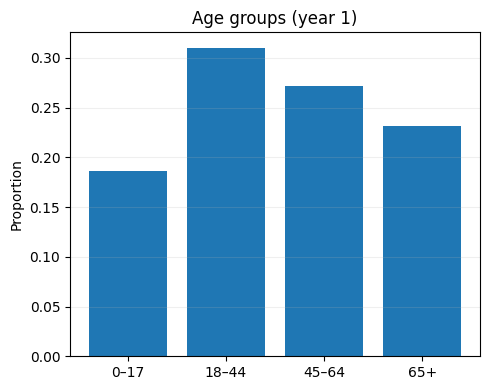

In [18]:
# group ages into bins 

age_col = "AGEY1X"
bins = [0, 17, 44, 64, 85]
labels = ["0–17", "18–44", "45–64", "65+"]

df_pre["AGE_GROUP"] = pd.cut(df_pre[age_col], bins=bins, labels=labels, right=True)

vc = df_pre["AGE_GROUP"].value_counts(normalize=True).sort_index()

plt.figure(figsize=(5,4))
plt.bar(vc.index.astype(str), vc.values)
plt.ylabel("Proportion")
plt.title("Age groups (year 1)")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

out_path = FIGURES_DIR / "Figure_A.1_age_groups.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved figure to:", out_path)
plt.show()


In [19]:
#Sex, race/ethnicity, region


for col in ["SEX", "RACETHX", "HISPANX", "REGIONY1", "REGIONY2"]:
    if col in df_pre.columns:
        print(f"\n{col} (counts):")
        print(df_pre[col].value_counts(dropna=False))
        print(f"{col} (proportions):")
        print(df_pre[col].value_counts(normalize=True, dropna=False))



SEX (counts):
SEX
2    4134
1    3678
Name: count, dtype: int64
SEX (proportions):
SEX
2    0.529186
1    0.470814
Name: proportion, dtype: float64

RACETHX (counts):
RACETHX
2    4172
1    1758
3    1140
4     475
5     267
Name: count, dtype: int64
RACETHX (proportions):
RACETHX
2    0.534050
1    0.225038
3    0.145929
4    0.060804
5    0.034178
Name: proportion, dtype: float64

HISPANX (counts):
HISPANX
2    6054
1    1758
Name: count, dtype: int64
HISPANX (proportions):
HISPANX
2    0.774962
1    0.225038
Name: proportion, dtype: float64

REGIONY1 (counts):
REGIONY1
3    3062
4    1973
2    1574
1    1203
Name: count, dtype: int64
REGIONY1 (proportions):
REGIONY1
3    0.391961
4    0.252560
2    0.201485
1    0.153994
Name: proportion, dtype: float64

REGIONY2 (counts):
REGIONY2
3    3057
4    1986
2    1567
1    1202
Name: count, dtype: int64
REGIONY2 (proportions):
REGIONY2
3    0.391321
4    0.254224
2    0.200589
1    0.153866
Name: proportion, dtype: float64


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Label mapping
sex_labels = {
    1: "Male",
    2: "Female",
}

race_labels = {
    1: "Hispanic",
    2: "Non-Hispanic White",
    3: "Non-Hispanic Black",
    4: "Non-Hispanic Asian",
    5: "Non-Hispanic Other / Multiple",
}

region_labels = {
    1: "Northeast",
    2: "Midwest",
    3: "South",
    4: "West",
}



Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.2_sex.png


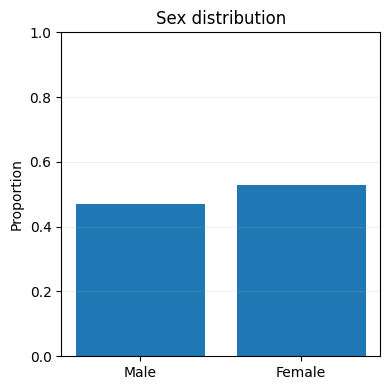

In [21]:
if "SEX" in df_pre.columns:
    s = df_pre["SEX"].dropna().astype(int)
    vc = s.value_counts(normalize=True).sort_index()

    labels = [sex_labels[k] for k in vc.index]
    values = vc.values

    plt.figure(figsize=(4, 4))
    plt.bar(labels, values)
    plt.ylim(0, 1)
    plt.ylabel("Proportion")
    plt.title("Sex distribution")
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()

    out_path = FIGURES_DIR / "Figure_A.2_sex.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print("Saved figure to:", out_path)
    plt.show()


Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.2_race.png


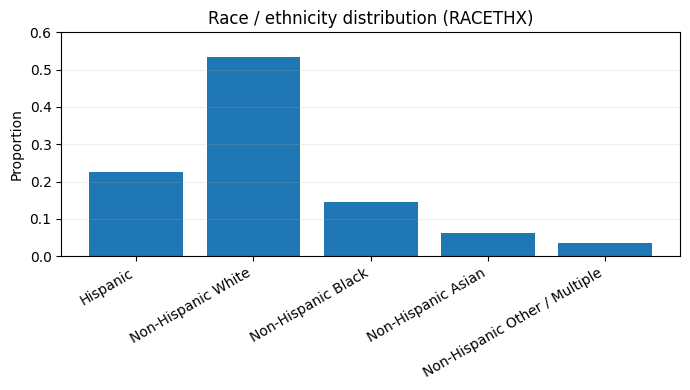

In [22]:
if "RACETHX" in df_pre.columns:
    s = df_pre["RACETHX"].dropna().astype(int)
    vc = s.value_counts(normalize=True).sort_index()

    labels = [race_labels[k] for k in vc.index]
    values = vc.values

    plt.figure(figsize=(7, 4))
    plt.bar(labels, values)
    plt.ylim(0, 0.6)
    plt.ylabel("Proportion")
    plt.title("Race / ethnicity distribution (RACETHX)")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()

    out_path = FIGURES_DIR / "Figure_A.2_race.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print("Saved figure to:", out_path)
    plt.show()


In [ ]:
region_cols = [c for c in ["REGIONY1", "REGIONY2"] if c in df_pre.columns]

region_props = {}
for col in region_cols:
    s = df_pre[col].dropna().astype(int)
    vc = s.value_counts(normalize=True).sort_index()
    region_props[col] = vc


cats = sorted({k for vc in region_props.values() for k in vc.index})
labels = [region_labels[k] for k in cats]

vals = []
for col in region_cols:
    row = [region_props[col].get(c, 0) for c in cats]
    vals.append(row)
vals = np.array(vals)


Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.2_region.png


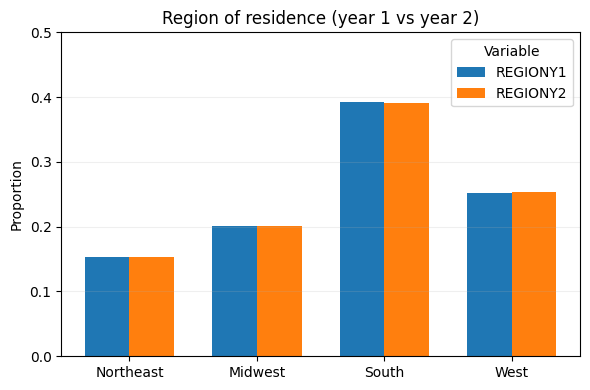

In [24]:
x = np.arange(len(cats))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))

for i, col in enumerate(region_cols):
    ax.bar(x + (i - 0.5) * width, vals[i], width, label=col)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylim(0, 0.5)
ax.set_ylabel("Proportion")
ax.set_title("Region of residence (year 1 vs year 2)")
ax.legend(title="Variable")
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()

out_path = FIGURES_DIR / "Figure_A.2_region.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved figure to:", out_path)
plt.show()


Females slightly outnumber males (about 53% vs 47%).

The race/ethnicity distribution is approximately 53% non-Hispanic White, 22% Hispanic, 15% non-Hispanic Black, 6% Asian, and 3–4% other / mixed race.

Regionally, the South has the largest share, followed by the West, Midwest, and Northeast, and the regional distributions in Year 1 and Year 2 are almost identical.

Education level: EDUCYR distribution (grouped categories)

In [ ]:
def barplot_with_pct(series_labels: pd.Series, title: str, xlabel: str = "", include_missing: bool = True):
    s = series_labels.copy()
    if include_missing:
        s = s.fillna("Missing")
    else:
        s = s.dropna()

    vc = s.value_counts(normalize=True)

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(vc.index.astype(str), vc.values)

    ax.set_ylabel("Proportion")
    ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)

    ax.grid(axis="y", alpha=0.2)
    ax.tick_params(axis="x", rotation=25)  

    # percent labels
    for bar, val in zip(bars, vc.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.1%}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    fig.tight_layout()

    
    print("Counts:")
    print(s.value_counts(dropna=False))
    print("\nProportions:")
    print(s.value_counts(normalize=True, dropna=False))

    return fig, ax


Counts:
EDUCYR
Grade 12 (HS grad)        1802
Some college (1–3 yrs)    1387
4 years college           1300
Elementary (1–8)          1137
5+ years college           934
High school (9–11)         692
Missing                    361
No school / K only         199
Name: count, dtype: int64

Proportions:
EDUCYR
Grade 12 (HS grad)        0.230671
Some college (1–3 yrs)    0.177547
4 years college           0.166411
Elementary (1–8)          0.145545
5+ years college          0.119560
High school (9–11)        0.088582
Missing                   0.046211
No school / K only        0.025474
Name: proportion, dtype: float64
Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.2.4_education_level.png


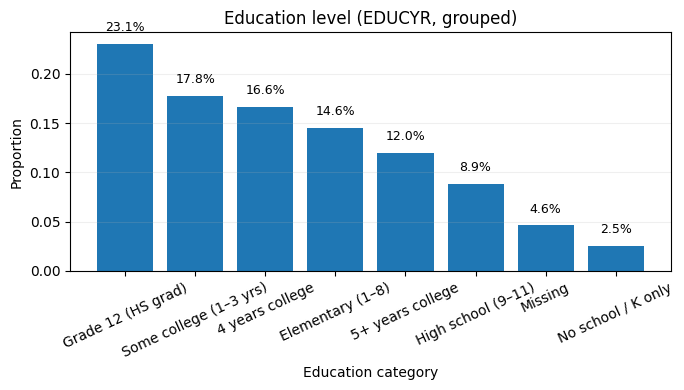

In [62]:
def recode_educyr(v):
    if pd.isna(v):
        return np.nan
    v = int(v)
    if v == 0:
        return "No school / K only"
    if 1 <= v <= 8:
        return "Elementary (1–8)"
    if 9 <= v <= 11:
        return "High school (9–11)"
    if v == 12:
        return "Grade 12 (HS grad)"
    if 13 <= v <= 15:
        return "Some college (1–3 yrs)"
    if v == 16:
        return "4 years college"
    if v >= 17:
        return "5+ years college"
    return np.nan

if "EDUCYR" in df_pre.columns:
    educ_grp = df_pre["EDUCYR"].map(recode_educyr)
    barplot_with_pct(
        educ_grp,
        title="Education level (EDUCYR, grouped)",
        xlabel="Education category",
        include_missing=True
    )



out_path = FIGURES_DIR / "Figure_A.2.4_education_level.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved figure to:", out_path)

plt.show()

### 2） SES

In [25]:
#Poverty category and family income

for col in ["POVCATY1", "POVCATY2"]:
    if col in df_pre.columns:
        print(f"\n{col}:")
        print(df_pre[col].value_counts(dropna=False))
        print(df_pre[col].value_counts(normalize=True, dropna=False))

for col in ["FAMINCY1", "FAMINCY2"]:
    if col in df_pre.columns:
        print(f"\n{col} summary:")
        print(df_pre[col].describe())



POVCATY1:
POVCATY1
5    2977
4    2179
1    1191
3    1093
2     372
Name: count, dtype: int64
POVCATY1
5    0.381080
4    0.278930
1    0.152458
3    0.139913
2    0.047619
Name: proportion, dtype: float64

POVCATY2:
POVCATY2
5    3067
4    2230
1    1112
3    1038
2     365
Name: count, dtype: int64
POVCATY2
5    0.392601
4    0.285458
1    0.142345
3    0.132873
2    0.046723
Name: proportion, dtype: float64

FAMINCY1 summary:
count      7812.000000
mean      91966.936508
std       85074.712509
min     -333392.000000
25%       32866.000000
50%       69172.500000
75%      126000.000000
max      674227.000000
Name: FAMINCY1, dtype: float64

FAMINCY2 summary:
count      7812.000000
mean      97115.945725
std       88182.013584
min        -230.000000
25%       36000.000000
50%       72860.000000
75%      135000.000000
max      747346.000000
Name: FAMINCY2, dtype: float64


In [26]:
pov_labels = {
    1: "Poor / negative",
    2: "Near poor",
    3: "Low income",
    4: "Middle income",
    5: "High income",
}


Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.3_poverty.png


/var/folders/nr/rpw2sxkn3gqfcrlz5z0bcfw80000gp/T/ipykernel_58779/3847491991.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right")


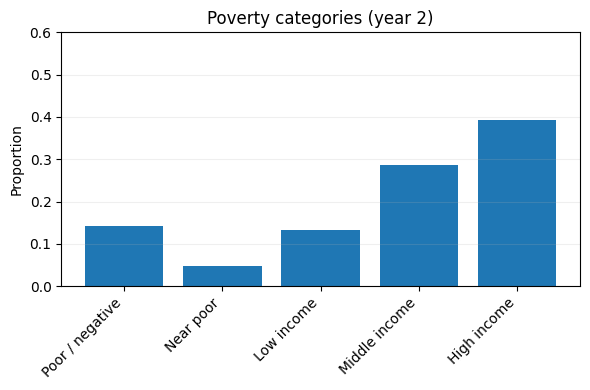

In [27]:
import numpy as np
import matplotlib.pyplot as plt

pov_col = "POVCATY2"

# only non-missing
mask = df_pre[pov_col].notna()
s = df_pre.loc[mask, pov_col].astype(int)

# Unweighted proportions
prop = s.value_counts(normalize=True).sort_index()

cats   = prop.index.tolist()
labels = [pov_labels.get(int(c), str(int(c))) for c in cats]
vals   = prop.values

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(labels, vals)
ax.set_ylim(0, 0.6)         
ax.set_ylabel("Proportion")
ax.set_title("Poverty categories (year 2)")
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()

out_path = FIGURES_DIR / "Figure_A.3_poverty.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved figure to:", out_path)
plt.show()


In 2023, the unweighted distribution of poverty categories was skewed toward higher income groups: approximately 39–40% of individuals lived in high-income families and 29% in middle-income families, while around 14% were classified as poor or with negative income, 5% as near poor, and 13% as low income.

Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.3_fam_income.png


/var/folders/nr/rpw2sxkn3gqfcrlz5z0bcfw80000gp/T/ipykernel_58779/3477066766.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


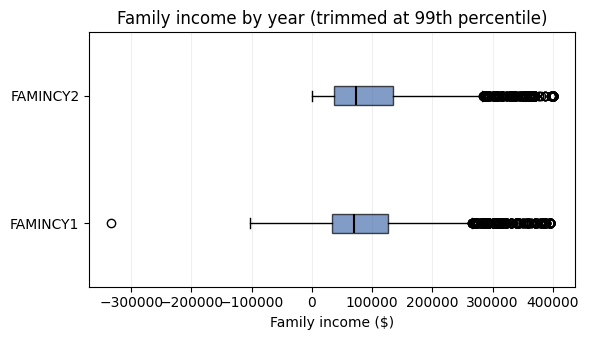

In [28]:
cols = [c for c in ["FAMINCY1", "FAMINCY2"] if c in df_pre.columns]

data = []
labels = []

for col in cols:
    s = df_pre[col].dropna()
    
    upper = s.quantile(0.99)
    s_clip = s.clip(upper=upper)
    data.append(s_clip.values)
    labels.append(col)

fig, ax = plt.subplots(figsize=(6, 3.5))

box = ax.boxplot(
    data,
    vert=False,           # horizontal boxplots 
    labels=labels,
    showfliers=True,
    patch_artist=True,
)

for patch in box["boxes"]:
    patch.set_facecolor("#4c72b0")
    patch.set_alpha(0.7)
for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

ax.set_xlabel("Family income ($)")
ax.set_title("Family income by year (trimmed at 99th percentile)")
ax.grid(axis="x", alpha=0.2)

fig.tight_layout()

out_path = FIGURES_DIR / "Figure_A.3_fam_income.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved figure to:", out_path)
plt.show()


**POVCAT plot**: The sample is dominated by middle-to-high income households, while poor and near-poor households still make up a meaningful share (roughly around one-third). This suggests the dataset covers a broad socioeconomic range—from poverty to high income—but is skewed toward higher-income groups.

**Family income boxplots**: Household income is right-skewed with a long upper tail, with a small number of families reporting very high incomes. The overall shapes are similar across the two years, and the median income is slightly higher in 2023, indicating a modest upward shift while the overall distribution remains largely stable.

Family size: FAMSZEY1 distribution (with optional “7+” grouping)

Counts:
FAMSZEY1
2          2246
4          1445
1          1441
3          1303
5           785
6           363
7+          228
Missing       1
Name: count, dtype: int64

Proportions:
FAMSZEY1
2          0.287506
4          0.184972
1          0.184460
3          0.166795
5          0.100486
6          0.046467
7+         0.029186
Missing    0.000128
Name: proportion, dtype: float64

FAMSZEY1 summary (raw):
count    7811.000000
mean        3.014595
std         1.687429
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        14.000000
Name: FAMSZEY1, dtype: float64


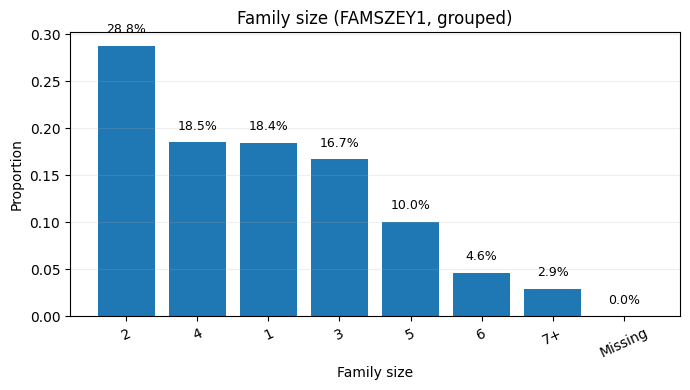

In [64]:
def recode_famsize(v):
    if pd.isna(v):
        return np.nan
    v = int(v)
    return "7+" if v >= 7 else str(v)

if "FAMSZEY1" in df_pre.columns:
    fam_grp = df_pre["FAMSZEY1"].map(recode_famsize)
    barplot_with_pct(
        fam_grp,
        title="Family size (FAMSZEY1, grouped)",
        xlabel="Family size",
        include_missing=True
    )

    # numeric summary (useful in text)
    print("\nFAMSZEY1 summary (raw):")
    print(df_pre["FAMSZEY1"].describe())


The grouped family size distribution is concentrated in smaller households. Two-person families are the most common (28.8%), followed by four-person (18.5%), one-person (18.4%), and three-person (16.7%) households. Larger families are less frequent: five-person households account for 10.0%, six-person for 4.6%, and seven or more for 2.9%. Missing values are negligible.

### 3)  Insurance status

In [29]:
#Insurance status

for col in ["INSCOVY1", "INSCOVY2", "INSURCY1", "INSURCY2"]:
    if col in df_pre.columns:
        print(f"\n{col}:")
        print(df_pre[col].value_counts(dropna=False))
        print(df_pre[col].value_counts(normalize=True, dropna=False))



INSCOVY1:
INSCOVY1
1    4691
2    2558
3     563
Name: count, dtype: int64
INSCOVY1
1    0.600486
2    0.327445
3    0.072069
Name: proportion, dtype: float64

INSCOVY2:
INSCOVY2
1    4767
2    2562
3     483
Name: count, dtype: int64
INSCOVY2
1    0.610215
2    0.327957
3    0.061828
Name: proportion, dtype: float64

INSURCY1:
INSURCY1
1    3905
2    1547
5     759
4     699
3     554
6     310
8      29
7       9
Name: count, dtype: int64
INSURCY1
1    0.499872
2    0.198029
5    0.097158
4    0.089478
3    0.070917
6    0.039683
8    0.003712
7    0.001152
Name: proportion, dtype: float64

INSURCY2:
INSURCY2
1    3903
2    1502
5     836
4     728
3     478
6     331
8      29
7       5
Name: count, dtype: int64
INSURCY2
1    0.499616
2    0.192268
5    0.107015
4    0.093190
3    0.061188
6    0.042371
8    0.003712
7    0.000640
Name: proportion, dtype: float64


Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.4.1_insurance_coverage.png


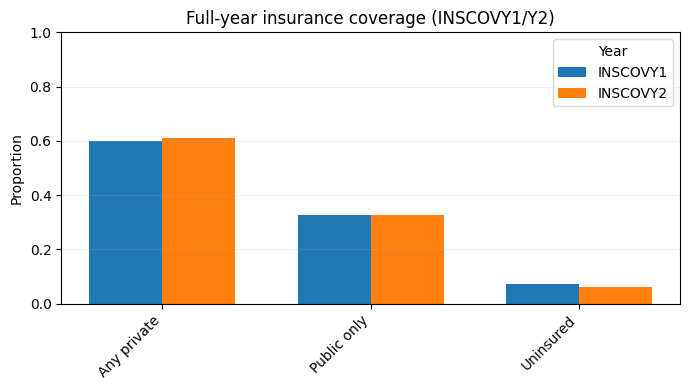

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# labels
inscov_labels = {
    1: "Any private",
    2: "Public only",
    3: "Uninsured",
}

cols = [c for c in ["INSCOVY1", "INSCOVY2"] if c in df_pre.columns]

# proportions
props = {}
for col in cols:
    s = df_pre[col].dropna().astype(int)
    vc = s.value_counts(normalize=True).sort_index()
    props[col] = vc

# order cagtegories
cats = sorted({k for vc in props.values() for k in vc.index})
labels = [inscov_labels.get(c, str(c)) for c in cats]

# matrix of values
vals = []
for col in cols:
    row = [props[col].get(c, 0) for c in cats]
    vals.append(row)
vals = np.array(vals)   # shape: (n_years, n_cats)

x = np.arange(len(cats))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))

for i, col in enumerate(cols):
    ax.bar(x + (i - 0.5) * width, vals[i], width, label=col)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Proportion")
ax.set_title("Full-year insurance coverage (INSCOVY1/Y2)")
ax.legend(title="Year")
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()

out_path = FIGURES_DIR / "Figure_A.4.1_insurance_coverage.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved figure to:", out_path)
plt.show()


In both years, around 60–61% of individuals had some form of private insurance for the full year, about one third were covered only by public programmes, and 6–7% were uninsured (INSCOVY1/Y2). The distribution of full-year coverage was very stable between 2022 and 2023, with a small decrease in the proportion uninsured.

Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.4.2_insurance_type.png


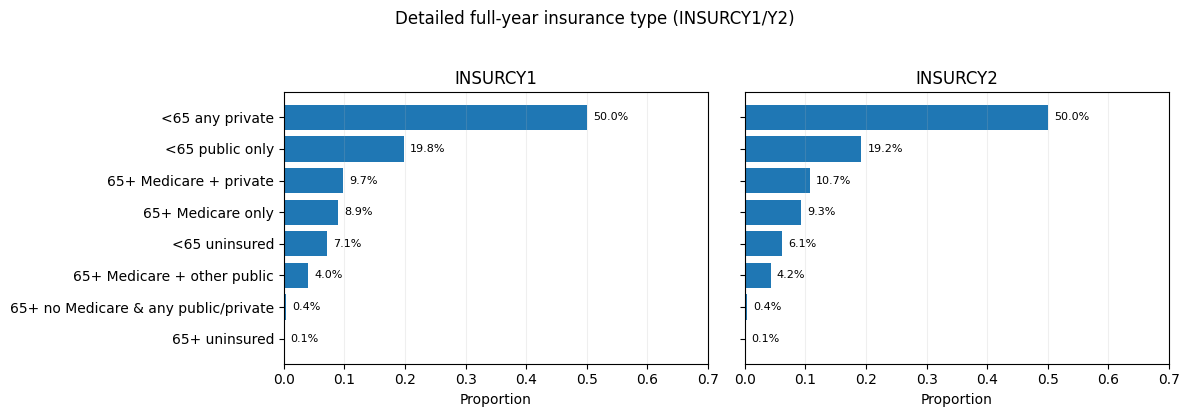

In [31]:
import numpy as np
import matplotlib.pyplot as plt

insurc_labels = {
    1: "<65 any private",
    2: "<65 public only",
    3: "<65 uninsured",
    4: "65+ Medicare only",
    5: "65+ Medicare + private",
    6: "65+ Medicare + other public",
    7: "65+ uninsured",
    8: "65+ no Medicare & any public/private",
}

ins_cols = [c for c in ["INSURCY1", "INSURCY2"] if c in df_pre.columns]

fig, axes = plt.subplots(1, len(ins_cols), figsize=(6 * len(ins_cols), 4), sharey=True)
if len(ins_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, ins_cols):
    s = df_pre[col].dropna().astype(int)

    # according to proportion ascending order
    vc = s.value_counts(normalize=True).sort_values(ascending=True)

    cats   = vc.index.tolist()
    labels = [insurc_labels.get(c, str(c)) for c in cats]
    values = vc.values

    y = np.arange(len(cats))
    bars = ax.barh(y, values)

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlim(0, 0.7)
    ax.set_xlabel("Proportion")
    ax.set_title(col)
    ax.grid(axis="x", alpha=0.2)
    
    

    # bar labels
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1%}",      
            va="center",
            fontsize=8,
        )

       

fig.suptitle("Detailed full-year insurance type (INSURCY1/Y2)", y=1.03)
fig.tight_layout()

out_path = FIGURES_DIR / "Figure_A.4.2_insurance_type.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved figure to:", out_path)
plt.show()


Looking at the more detailed full-year insurance categories (INSURCY1/Y2), roughly half of individuals younger than 65 had some private coverage, about one fifth were covered only by public programmes, and around 6–7% were uninsured. Among those aged 65 or older, the vast majority were covered by Medicare, either alone or in combination with private or other public coverage, while the proportion of older adults uninsured was extremely small (<0.1%). The distribution of these detailed insurance types was very similar between 2022 and 2023, with a slight decrease in the proportion of uninsured individuals and a small increase in Medicare+private coverage among older adults.

### 4) Employment

In [33]:
import matplotlib.pyplot as plt

work_cols = [c for c in ["EVRWRKY1", "EVRWRKY2"] if c in df_pre.columns]


work_map = {1.0: "Yes", 2.0: "No"}

for col in work_cols:
    s = df_pre[col]
    cat = s.map(work_map)
    print(f"\n{col} value counts (incl. missing):")
    print(cat.value_counts(dropna=False))
    print("Proportion 'Yes':", s.eq(1).mean())



EVRWRKY1 value counts (incl. missing):
EVRWRKY1
NaN    5484
Yes    1524
No      804
Name: count, dtype: int64
Proportion 'Yes': 0.19508448540706605

EVRWRKY2 value counts (incl. missing):
EVRWRKY2
NaN    5586
Yes    1457
No      769
Name: count, dtype: int64
Proportion 'Yes': 0.1865079365079365


Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.5.1_ever_worked.png


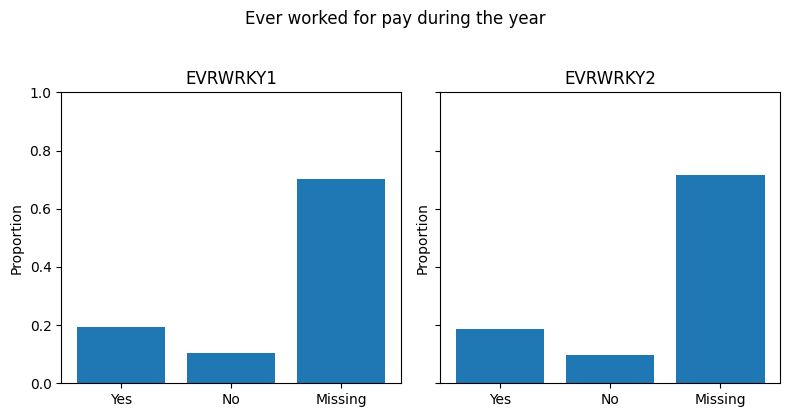

In [35]:
fig, axes = plt.subplots(1, len(work_cols), figsize=(4 * len(work_cols), 4), sharey=True)

if len(work_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, work_cols):
    s = df_pre[col]
    cat = s.map(work_map)

    
    vc = cat.value_counts(normalize=True, dropna=False)

    
    idx_order = ["Yes", "No", None]
    labels = ["Yes", "No", "Missing"]
    values = [vc.get("Yes", 0), vc.get("No", 0), vc.get(np.nan, 0)]

    ax.bar(labels, values)
    ax.set_ylim(0, 1)
    ax.set_title(col)
    ax.set_ylabel("Proportion")
    ax.grid(False)

fig.suptitle("Ever worked for pay during the year", y=1.03)
fig.tight_layout()

out_path = FIGURES_DIR / "Figure_A.5.1_ever_worked.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved figure to:", out_path)
plt.show()


/var/folders/nr/rpw2sxkn3gqfcrlz5z0bcfw80000gp/T/ipykernel_58779/3667534983.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=25, ha="right")
/var/folders/nr/rpw2sxkn3gqfcrlz5z0bcfw80000gp/T/ipykernel_58779/3667534983.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=25, ha="right")
/var/folders/nr/rpw2sxkn3gqfcrlz5z0bcfw80000gp/T/ipykernel_58779/3667534983.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=25, ha="right")


Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.5.3_employed_vs_unemployed.png


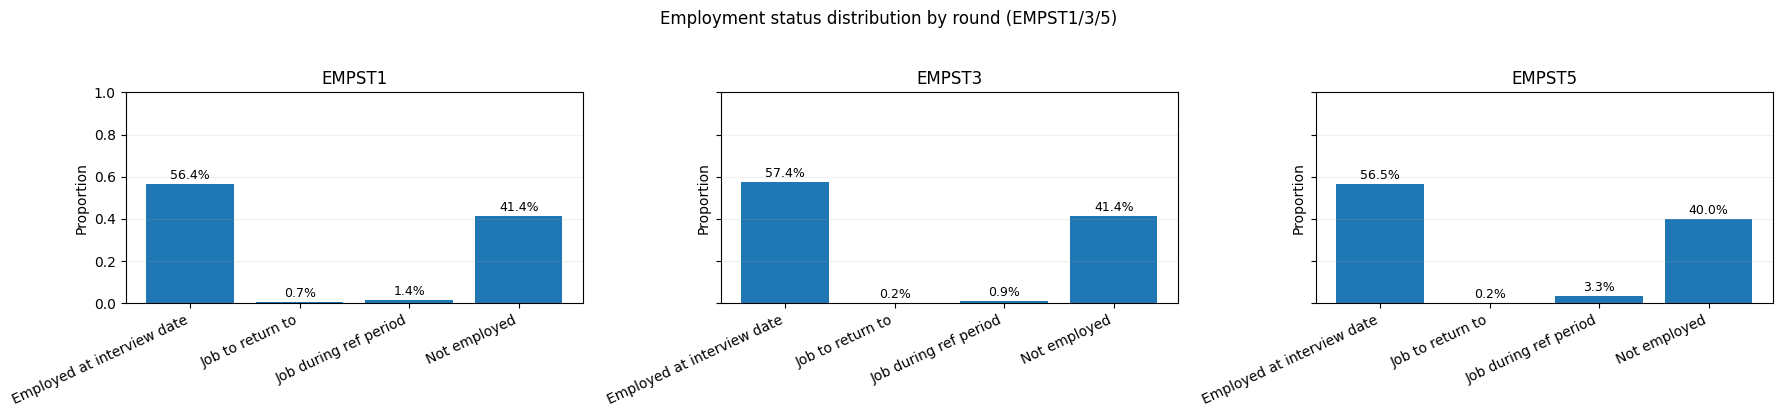

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

emp_map = {
    1: "Employed at interview date",
    2: "Job to return to",
    3: "Job during ref period",
    4: "Not employed",
}

round_cols = [c for c in ["EMPST1", "EMPST3", "EMPST5"] if c in df_pre.columns]

fig, axes = plt.subplots(1, len(round_cols), figsize=(6 * len(round_cols), 4), sharey=True)
if len(round_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, round_cols):
    s = df_pre[col].dropna().astype(int)
    vc = s.value_counts(normalize=True).sort_index()  # 1,2,3,4 order

    cats = [1, 2, 3, 4]
    labels = [emp_map[c] for c in cats]
    vals = [vc.get(c, 0) for c in cats]

    bars = ax.bar(labels, vals)
    ax.set_title(col)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Proportion")
    ax.grid(axis="y", alpha=0.2)
    ax.set_xticklabels(labels, rotation=25, ha="right")

    # % labels
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{val:.1%}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

fig.suptitle("Employment status distribution by round (EMPST1/3/5)", y=1.03)
fig.tight_layout()

out_path = FIGURES_DIR / "Figure_A.5.3_employed_vs_unemployed.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved figure to:", out_path)
plt.show()


In [68]:
AGE_COL  = "AGEY1X"      
WORK_COL = "EVRWRKY1"   

missing_mask = df_pre[WORK_COL].isna()


q25, q50, q75 = df_pre.loc[missing_mask, AGE_COL].quantile([0.25, 0.5, 0.75])
print(f"Age (missing group) quartiles: Q1={q25:.1f}, Median={q50:.1f}, Q3={q75:.1f}")


Age (missing group) quartiles: Q1=19.0, Median=37.0, Q3=53.0


Among respondents with non-missing values, around two thirds reported having worked for pay at some point during the year, while about one third did not. A large share of records are coded as inapplicable, reflecting children and others not in the labour force.

In [ ]:
# PERSON'S UNEMPLOYMENT COMP INCOME  
for col in ["UNEMPY1X", "UNEMPY2X"]:
    if col in df_pre.columns:
        print(f"\n{col} summary:")
        print(df_pre[col].describe())



UNEMPY1X summary:
count    7812.000000
mean       56.106759
std       564.708845
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      9169.000000
Name: UNEMPY1X, dtype: float64

UNEMPY2X summary:
count     7812.000000
mean        65.687276
std        650.218032
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      12824.000000
Name: UNEMPY2X, dtype: float64


Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.5.2_unemployment_compensation.png


/var/folders/nr/rpw2sxkn3gqfcrlz5z0bcfw80000gp/T/ipykernel_58779/3925387543.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


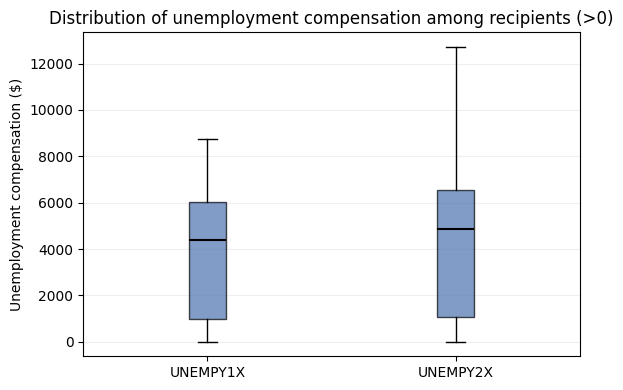

In [36]:
import numpy as np
import matplotlib.pyplot as plt

unemp_cols = [c for c in ["UNEMPY1X", "UNEMPY2X"] if c in df_pre.columns]

data = []
labels = []

for col in unemp_cols:
    s_pos = df_pre[col].dropna()
    s_pos = s_pos[s_pos > 0]      
    if len(s_pos) == 0:
        continue

   
    upper = s_pos.quantile(0.99)
    s_clip = s_pos.clip(upper=upper)

    data.append(s_clip.values)
    labels.append(col)

if data:
    fig, ax = plt.subplots(figsize=(6, 4))

    box = ax.boxplot(
        data,
        labels=labels,
        showfliers=True,   
        patch_artist=True   
    )

  
    for patch in box["boxes"]:
        patch.set_facecolor("#4c72b0")
        patch.set_alpha(0.7)
    for median in box["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)

    ax.set_ylabel("Unemployment compensation ($)")
    ax.set_title("Distribution of unemployment compensation among recipients (>0)")
    ax.grid(axis="y", alpha=0.2)  
    fig.tight_layout()

    out_path = FIGURES_DIR / "Figure_A.5.2_unemployment_compensation.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print("Saved figure to:", out_path)
    plt.show()


In the overall sample, the vast majority of individuals received no unemployment compensation in both 2022 and 2023 (at least 75% of observations are 0).

Among the small subgroup who did receive benefits, the amounts are substantial and strongly right-skewed: the median is around $4–5k, the upper quartile is around $6–7k, and a small number of recipients received more than $9k (2022) and even over $12k (2023).

The overall pattern is similar across the two years, but the typical benefit amount among recipients is slightly higher in 2023.

### 5) Self-reported Health status variables

In [39]:
health_cols = [c for c in ["RTHLTH1", "RTHLTH3", "RTHLTH5",
                           "MNHLTH1", "MNHLTH3", "MNHLTH5"]
               if c in df_pre.columns]

for col in health_cols:
    print(f"\n{col}:")
    print(df_pre[col].value_counts(dropna=False).sort_index())



RTHLTH1:
RTHLTH1
1.0    2218
2.0    2449
3.0    2096
4.0     811
5.0     218
NaN      20
Name: count, dtype: int64

RTHLTH3:
RTHLTH3
1.0    1998
2.0    2584
3.0    2259
4.0     784
5.0     179
NaN       8
Name: count, dtype: int64

RTHLTH5:
RTHLTH5
1.0    1854
2.0    2671
3.0    2323
4.0     772
5.0     187
NaN       5
Name: count, dtype: int64

MNHLTH1:
MNHLTH1
1.0    2552
2.0    2314
3.0    2137
4.0     650
5.0     130
NaN      29
Name: count, dtype: int64

MNHLTH3:
MNHLTH3
1.0    2349
2.0    2423
3.0    2209
4.0     681
5.0     139
NaN      11
Name: count, dtype: int64

MNHLTH5:
MNHLTH5
1.0    2214
2.0    2502
3.0    2287
4.0     662
5.0     140
NaN       7
Name: count, dtype: int64


In [38]:
health_labels = {
    1: "Excellent",
    2: "Very good",
    3: "Good",
    4: "Fair",
    5: "Poor",
}


/var/folders/nr/rpw2sxkn3gqfcrlz5z0bcfw80000gp/T/ipykernel_58779/3242467807.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right")
/var/folders/nr/rpw2sxkn3gqfcrlz5z0bcfw80000gp/T/ipykernel_58779/3242467807.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right")
/var/folders/nr/rpw2sxkn3gqfcrlz5z0bcfw80000gp/T/ipykernel_58779/3242467807.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right")


Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.6.1_general_health.png


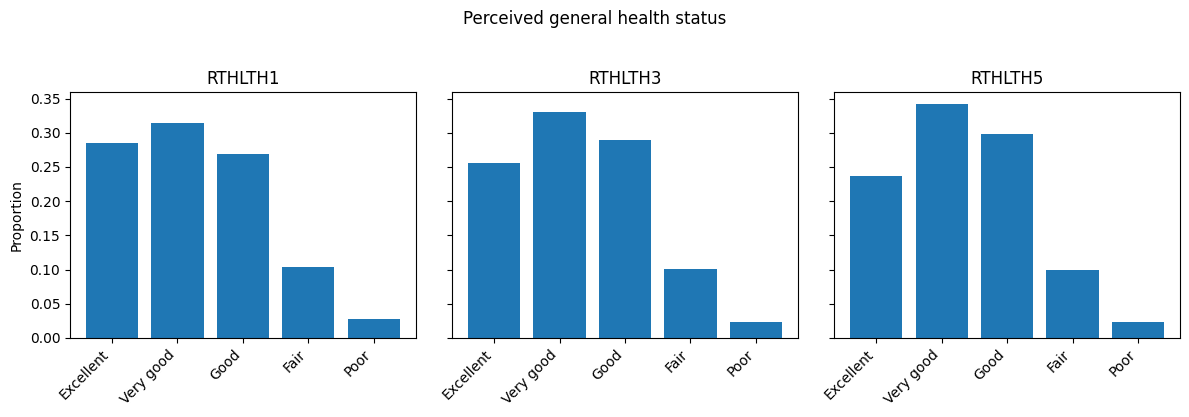

In [40]:
rth_cols = [c for c in ["RTHLTH1", "RTHLTH3", "RTHLTH5"] if c in df_pre.columns]

fig, axes = plt.subplots(1, len(rth_cols), figsize=(4 * len(rth_cols), 4), sharey=True)

for ax, col in zip(axes, rth_cols):
    vc = df_pre[col].value_counts(normalize=True).sort_index()
    labels = [health_labels.get(k, str(k)) for k in vc.index]
    ax.bar(labels, vc.values)
    ax.set_title(col)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.grid(False)

axes[0].set_ylabel("Proportion")
fig.suptitle("Perceived general health status", y=1.03)
fig.tight_layout()

out_path = FIGURES_DIR / "Figure_A.6.1_general_health.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved figure to:", out_path)
plt.show()


Across the three interview rounds, self-rated general health was skewed towards the favourable categories: around 85–87% of respondents reported their health as good, very good or excellent, while approximately 12–13% reported fair or poor health. The distribution was very stable over time, with a small shift from “excellent” towards “very good” and “good” between rounds, consistent with gradual ageing rather than abrupt changes in health.

Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.6.2_mental_health.png


/var/folders/nr/rpw2sxkn3gqfcrlz5z0bcfw80000gp/T/ipykernel_58779/3794571392.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right")
/var/folders/nr/rpw2sxkn3gqfcrlz5z0bcfw80000gp/T/ipykernel_58779/3794571392.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right")
/var/folders/nr/rpw2sxkn3gqfcrlz5z0bcfw80000gp/T/ipykernel_58779/3794571392.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right")


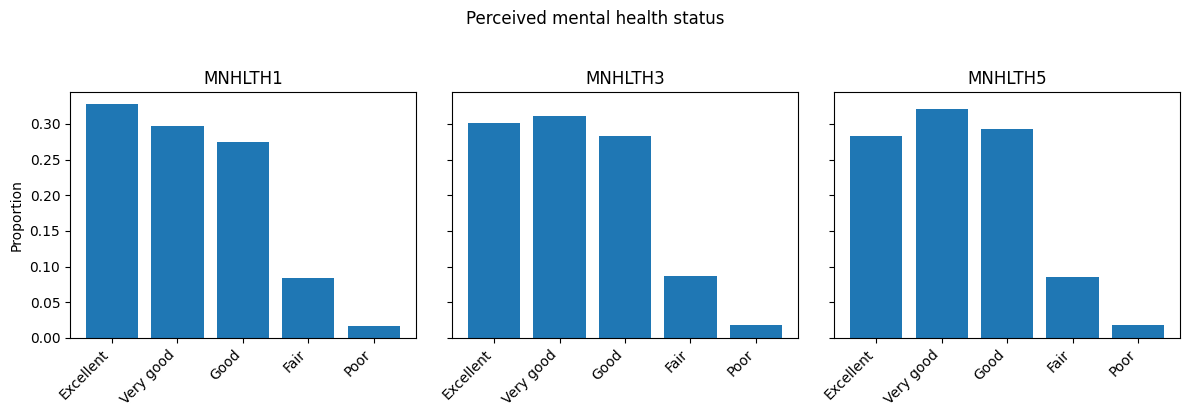

In [41]:
mnh_cols = [c for c in ["MNHLTH1", "MNHLTH3", "MNHLTH5"] if c in df_pre.columns]

fig, axes = plt.subplots(1, len(mnh_cols), figsize=(4 * len(mnh_cols), 4), sharey=True)

for ax, col in zip(axes, mnh_cols):
    vc = df_pre[col].value_counts(normalize=True).sort_index()
    labels = [health_labels.get(k, str(k)) for k in vc.index]
    ax.bar(labels, vc.values)
    ax.set_title(col)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.grid(False)

axes[0].set_ylabel("Proportion")
fig.suptitle("Perceived mental health status", y=1.03)
fig.tight_layout()

out_path = FIGURES_DIR / "Figure_A.6.2_mental_health.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved figure to:", out_path)
plt.show()


Self-rated mental health shows a very similar pattern, with roughly 88–90% of respondents rating their mental health as good, very good or excellent and only around 10% reporting fair or poor mental health in each round. Compared with general health, the proportion reporting fair or poor mental health is slightly lower, and the distribution remains remarkably stable across rounds 1, 3 and 5.

Overall, both general and mental health are skewed towards the favourable end of the scale, with only a small minority of respondents reporting fair or poor health, and the distributions show little change over the two-year follow-up.

Chronic condition prevalence and multimorbidity 

In [42]:
chronic_cols = [
    "HIBPDXY1", "CHDDXY1", "STRKDXY1", "CHOLDXY1", "ASTHDXY1", "DIABDXY1_M18"
]
chronic_cols = [c for c in chronic_cols if c in df_pre.columns]

for col in chronic_cols:
    print(f"\n{col} prevalence (year 1):")
    print(df_pre[col].value_counts(dropna=False))
    print("Proportion with condition:", (df_pre[col] == 1).mean())


HIBPDXY1 prevalence (year 1):
HIBPDXY1
2.0    4003
1.0    2364
NaN    1445
Name: count, dtype: int64
Proportion with condition: 0.30261136712749614

CHDDXY1 prevalence (year 1):
CHDDXY1
2.0    6023
NaN    1440
1.0     349
Name: count, dtype: int64
Proportion with condition: 0.04467485919098822

STRKDXY1 prevalence (year 1):
STRKDXY1
2.0    6067
NaN    1441
1.0     304
Name: count, dtype: int64
Proportion with condition: 0.03891449052739376

CHOLDXY1 prevalence (year 1):
CHOLDXY1
2.0    4142
1.0    2223
NaN    1447
Name: count, dtype: int64
Proportion with condition: 0.28456221198156684

ASTHDXY1 prevalence (year 1):
ASTHDXY1
2.0    6759
1.0    1051
NaN       2
Name: count, dtype: int64
Proportion with condition: 0.13453661034306197

DIABDXY1_M18 prevalence (year 1):
DIABDXY1_M18
2.0    6899
1.0     910
NaN       3
Name: count, dtype: int64
Proportion with condition: 0.11648745519713262


Around 30% of individuals report a diagnosis of hypertension and 29% report high cholesterol in year 1, making these the most prevalent cardiometabolic risk factors in the sample.

Asthma and diabetes are also common, with prevalences of about 14% and 12%, respectively.

Manifest cardiovascular disease is less frequent: only about 4–5% of individuals report coronary heart disease and roughly 4% report ever having had a stroke.

Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.7_multimorbidity.png


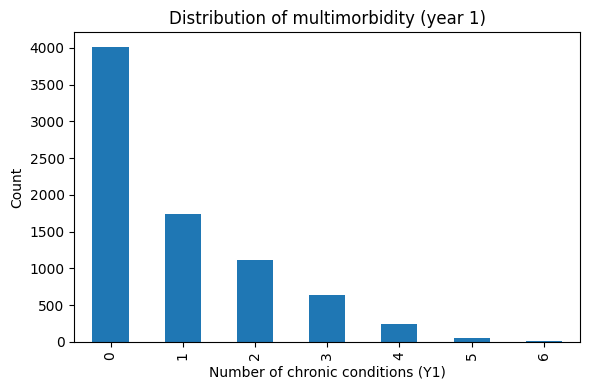

In [43]:
#Multimorbidity count (number of chronic conditions present, year 1):


df_pre["MULTIMORBIDITY_Y1"] = df_pre[chronic_cols].eq(1).sum(axis=1)

plt.figure(figsize=(6,4))
df_pre["MULTIMORBIDITY_Y1"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Number of chronic conditions (Y1)")
plt.ylabel("Count")
plt.title("Distribution of multimorbidity (year 1)")
plt.tight_layout()

out_path = FIGURES_DIR / "Figure_A.7_multimorbidity.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved figure to:", out_path)
plt.show()

In [69]:
# counts + percent for MULTIMORBIDITY_Y1 (descending by count)
summary = (
    df_pre["MULTIMORBIDITY_Y1"]
    .value_counts(dropna=False)              # include NaN if any
    .to_frame(name="count")
)

summary["percent"] = (summary["count"] / summary["count"].sum() * 100).round(2)


print(summary)


                   count  percent
MULTIMORBIDITY_Y1                
0                   4010    51.33
1                   1735    22.21
2                   1117    14.30
3                    639     8.18
4                    249     3.19
5                     53     0.68
6                      9     0.12


Just over half of the sample (≈50%) do not report any of the six selected chronic conditions in year 1.

About one in five individuals has exactly one of these conditions, and roughly a quarter have two or more.

A small but non-negligible group (around 3–4%) lives with four or more of these conditions, representing a highly multimorbid subgroup likely to be at particularly high risk of future utilisation and expenditures.

### 6）Missingness patterns

In [42]:
#Variable-wise missing rate

missing_ratio = df_pre.isna().mean().sort_values(ascending=False)
missing_ratio.head(20)


MORECOVR    0.989247
PREVCOVR    0.885177
EVRWRKY2    0.715054
EVRWRKY1    0.701997
EMPST1      0.185868
CHOLDXY1    0.185228
CHOLDXY2    0.185228
HIBPDXY2    0.184972
HIBPDXY1    0.184972
STRKDXY1    0.184460
STRKDXY2    0.184460
CHDDXY2     0.184332
CHDDXY1     0.184332
EMPST2      0.171659
EMPST3      0.168843
EMPST4      0.159882
EMPST5      0.156170
EDUCYR      0.046211
MNHLTH1     0.003712
RTHLTH1     0.002560
dtype: float64

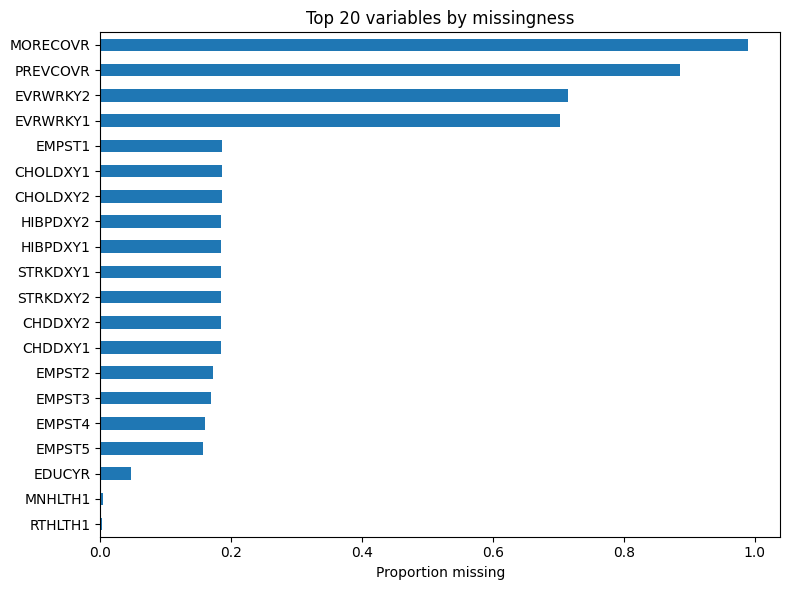

In [ ]:
plt.figure(figsize=(8, 6))

ax = missing_ratio.head(20).plot(kind="barh")

ax.set_xlabel("Proportion missing")
ax.set_title("Top 20 variables by missingness")

ax.invert_yaxis()     

plt.tight_layout()
plt.show()

- A few variables (e.g., MORECOVR, PREVCOVR) are almost entirely missing and can be dropped from the feature set.

- Employment-related variables have substantial missingness, so they should be used cautiously.

- Chronic condition and self-reported health variables show moderate missingness, but they are still worth retaining.

- Key demographic, socioeconomic status (SES), and utilization/expenditure variables have very low missingness, which is favorable for modeling.

In [ ]:
#Missingness for key groups of variables


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


groups = {
    "Demographics": [
        "AGEY1X", "AGEY2X", "SEX", "RACETHX", "HISPANX",
        "REGIONY1", "REGIONY2",
    ],
    "SES": [
        "FAMINCY1", "FAMINCY2",
        "POVCATY1", "POVCATY2",
        "POVLEVY1", "POVLEVY2",
    ],
    "Insurance": [
        "INSCOVY1", "INSCOVY2",
        "INSURCY1", "INSURCY2",
        "UNINSY1", "UNINSY2",
        "PREVCOVR", "MORECOVR",
    ],
    "Employment": [
        "EVRWRKY1", "EVRWRKY2",
        "EMPST1", "EMPST2", "EMPST3", "EMPST4", "EMPST5",
    ],
    "Health status": [
        "RTHLTH1", "RTHLTH3", "RTHLTH5",
        "MNHLTH1", "MNHLTH3", "MNHLTH5",
    ],
    "Chronic conditions": [
        "HIBPDXY1", "HIBPDXY2",
        "CHDDXY1", "CHDDXY2",
        "STRKDXY1", "STRKDXY2",
        "CHOLDXY1", "CHOLDXY2",
        "ASTHDXY1", "ASTHDXY2",
        "DIABDXY1_M18", "DIABDXY2_M18",
    ],
    "Utilisation & cost": [
        "TOTEXPY1", "TOTEXPY2",
        "ERTOTY1", "ERTOTY2",
        "IPDISY1", "IPDISY2",
        "TOTTCHY1", "TOTTCHY2",
    ],
}


groups = {
    name: [c for c in cols if c in df_pre.columns]
    for name, cols in groups.items()
}


group_missing = {}
for name, cols in groups.items():
    if cols:
        group_missing[name] = df_pre[cols].isna().mean().mean()
    else:
        group_missing[name] = np.nan

group_missing




{'Demographics': np.float64(0.0),
 'SES': np.float64(0.0),
 'Insurance': np.float64(0.23430299539170507),
 'Employment': np.float64(0.32278180089239994),
 'Health status': np.float64(0.0017067759003242873),
 'Chronic conditions': np.float64(0.12327188940092167),
 'Utilisation & cost': np.float64(0.0)}

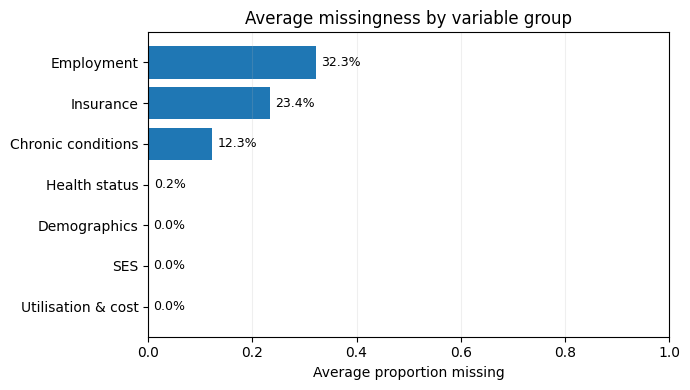

In [ ]:

group_missing_clean = {k: v for k, v in group_missing.items() if not np.isnan(v)}


items  = sorted(group_missing_clean.items(), key=lambda x: x[1], reverse=True)
groups = [k for k, v in items]
values = [v for k, v in items]

fig, ax = plt.subplots(figsize=(7, 4))

y = np.arange(len(groups))
bars = ax.barh(y, values)


ax.set_yticks(y)
ax.set_yticklabels(groups)


ax.invert_yaxis()

ax.set_xlabel("Average proportion missing")
ax.set_title("Average missingness by variable group")
ax.set_xlim(0, 1)
ax.grid(axis="x", alpha=0.2)


for bar, v in zip(bars, values):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{v:.1%}",           
        va="center",
        fontsize=9,
    )

fig.tight_layout()
plt.show()


## 5. Targets distribution

In [46]:
#Basic summary for TOTEXP

for col in ["TOTEXPY1", "TOTEXPY2"]:
    if col in df_pre.columns:
        print(f"\n{col} summary:")
        print(df_pre[col].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))



TOTEXPY1 summary:
count      7812.000000
mean       7582.318356
std       22897.826434
min           0.000000
10%           0.000000
25%         335.500000
50%        1812.500000
75%        6597.500000
90%       18105.900000
95%       31773.300000
99%       82638.700000
max      802849.000000
Name: TOTEXPY1, dtype: float64

TOTEXPY2 summary:
count      7812.000000
mean       8304.398874
std       22264.311550
min           0.000000
10%           0.000000
25%         272.750000
50%        1815.500000
75%        7268.250000
90%       20008.800000
95%       37300.450000
99%       93432.080000
max      574675.000000
Name: TOTEXPY2, dtype: float64


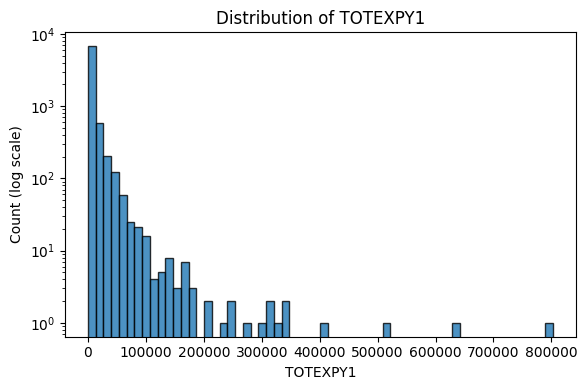

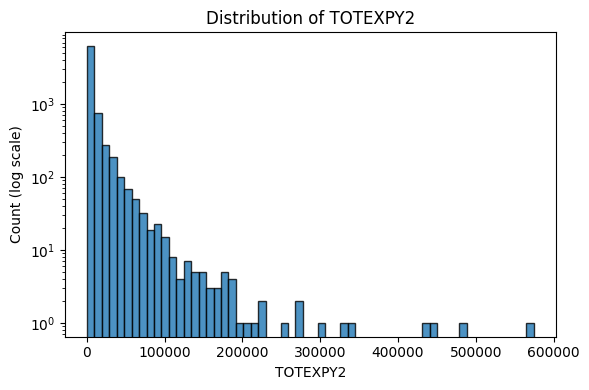

In [47]:
#Histograms on original scale (log y-axis)
for col in ["TOTEXPY1", "TOTEXPY2"]:
    if col in df_pre.columns:
        plt.figure(figsize=(6,4))
        df_pre[col].dropna().hist(bins=60, edgecolor="black", alpha=0.8)
        plt.yscale("log")
        plt.xlabel(col)
        plt.ylabel("Count (log scale)")
        plt.title(f"Distribution of {col}")
        plt.tight_layout()
        plt.grid(False) 
        plt.show()


On the original dollar scale, both TOTEXPY1 and TOTEXPY2 exhibit a highly skewed, heavy-tailed distribution (Figure X). After log(1 + x) transformation, the distributions become much more symmetric, which motivates the use of log-transformed expenditures in some of the regression models.

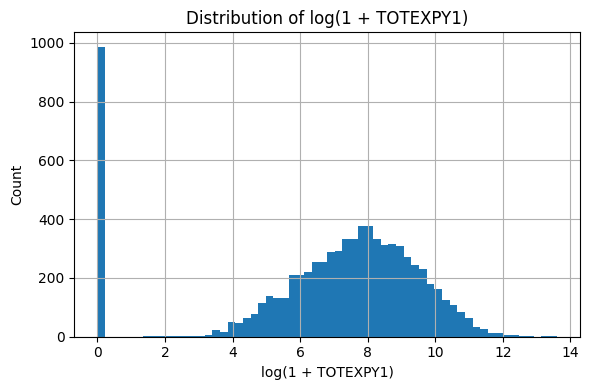

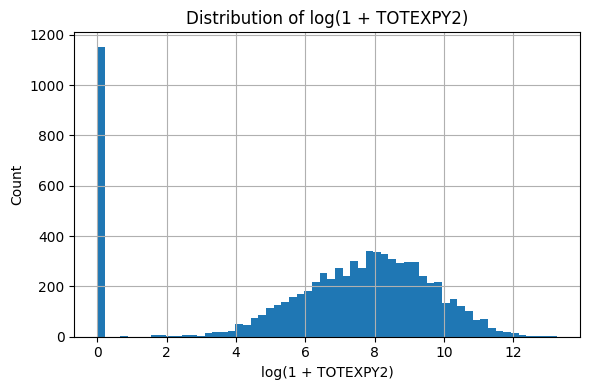

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

for col in ["TOTEXPY1", "TOTEXPY2"]:
    
        # log(1 + x) 
        plt.figure(figsize=(6,4))
        np.log1p(df_pre[col].dropna()).hist(bins=60)
        plt.xlabel(f"log(1 + {col})")
        plt.ylabel("Count")
        plt.title(f"Distribution of log(1 + {col})")
        plt.tight_layout()
        plt.show()


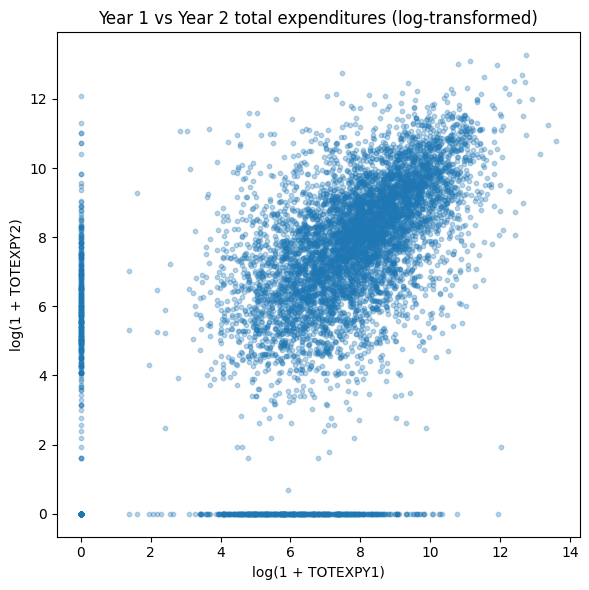

In [49]:
#Scatter plot: log(1 + TOTEXPY1) vs log(1 + TOTEXPY2)

if {"TOTEXPY1", "TOTEXPY2"} <= set(df_pre.columns):
    plt.figure(figsize=(6,6))
    plt.scatter(
        np.log1p(df_pre["TOTEXPY1"]),
        np.log1p(df_pre["TOTEXPY2"]),
        alpha=0.3,
        s=10
    )
    plt.xlabel("log(1 + TOTEXPY1)")
    plt.ylabel("log(1 + TOTEXPY2)")
    plt.title("Year 1 vs Year 2 total expenditures (log-transformed)")
    plt.tight_layout()
    plt.show()


This plots log-transformed total expenditures in year 1 versus year 2. There is a clear positive association—individuals with higher spending in 2022 tend to have higher spending in 2023—but the cloud of points is relatively dispersed, indicating substantial year-to-year variability. A non-negligible number of individuals have zero expenditures in one year and positive expenditures in the other, highlighting the need to account for additional predictors beyond baseline spending.

In [50]:
import numpy as np

mask = df_pre[["TOTEXPY1", "TOTEXPY2"]].notna().all(axis=1)
x = np.log1p(df_pre.loc[mask, "TOTEXPY1"])
y = np.log1p(df_pre.loc[mask, "TOTEXPY2"])
x.corr(y)


np.float64(0.6625809110801745)

Utilisation & conditions

In [51]:
#Prevalence of any ED visit / inpatient stay

# Create binary indicators for any ED / IP in each year
df_util = df_pre.copy()

if "ERTOTY1" in df_util.columns:
    df_util["ANY_ED_Y1"] = (df_util["ERTOTY1"] > 0).astype(int)
if "ERTOTY2" in df_util.columns:
    df_util["ANY_ED_Y2"] = (df_util["ERTOTY2"] > 0).astype(int)

if "IPDISY1" in df_util.columns:
    df_util["ANY_IP_Y1"] = (df_util["IPDISY1"] > 0).astype(int)
if "IPDISY2" in df_util.columns:
    df_util["ANY_IP_Y2"] = (df_util["IPDISY2"] > 0).astype(int)

for col in ["ANY_ED_Y1", "ANY_ED_Y2", "ANY_IP_Y1", "ANY_IP_Y2"]:
    if col in df_util.columns:
        print(f"\n{col}:")
        print(df_util[col].value_counts(dropna=False))
        print("Proportion with event:", df_util[col].mean())



ANY_ED_Y1:
ANY_ED_Y1
0    6719
1    1093
Name: count, dtype: int64
Proportion with event: 0.13991295442908347

ANY_ED_Y2:
ANY_ED_Y2
0    6697
1    1115
Name: count, dtype: int64
Proportion with event: 0.14272913466461853

ANY_IP_Y1:
ANY_IP_Y1
0    7348
1     464
Name: count, dtype: int64
Proportion with event: 0.059395801331285206

ANY_IP_Y2:
ANY_IP_Y2
0    7245
1     567
Name: count, dtype: int64
Proportion with event: 0.07258064516129033


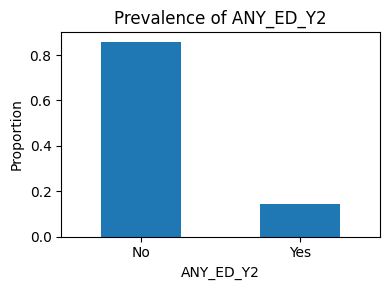

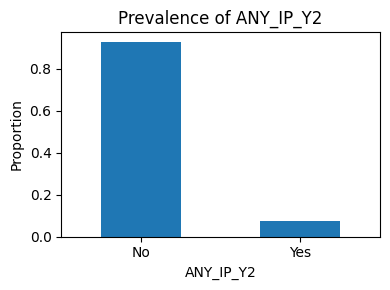

In [52]:
#Simple barplot for year-2 outcomes:

for col in ["ANY_ED_Y2", "ANY_IP_Y2"]:
    if col in df_util.columns:
        plt.figure(figsize=(4,3))
        df_util[col].value_counts(normalize=True).sort_index().plot(kind="bar")
        plt.xticks([0,1], ["No", "Yes"], rotation=0)
        plt.ylabel("Proportion")
        plt.title(f"Prevalence of {col}")
        plt.tight_layout()
        plt.show()


**Incidence of any ED visit / inpatient stay (ANY_ED_Y, ANY_IP_Y)**

- Emergency department (ED): The share of individuals with at least one ED visit is ~14.0% in Year 1 and ~14.3% in Year 2, indicating a very similar pattern across years (roughly about one in seven people had an ED visit within a year).

- Inpatient (IP): Inpatient stays are less common, with ~5.9% in Year 1 and ~7.3% in Year 2. This suggests about 6–7% of individuals had at least one hospitalization, and the rate is slightly higher in Year 2.

The bar charts make the class imbalance clear: “No” dominates (~0.86 for ED; ~0.93 for IP) while “Yes” is much smaller (~0.14 for ED; ~0.07 for IP). This is a typical imbalanced binary classification setting, so class imbalance should be considered when modeling ANY_ED_Y2 and ANY_IP_Y2.

In [53]:
#Counts of ED visits / inpatient discharges

for col in ["ERTOTY1", "ERTOTY2", "IPDISY1", "IPDISY2"]:
    if col in df_pre.columns:
        print(f"\n{col} summary:")
        print(df_pre[col].describe())



ERTOTY1 summary:
count    7812.000000
mean        0.203277
std         0.629289
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        12.000000
Name: ERTOTY1, dtype: float64

ERTOTY2 summary:
count    7812.000000
mean        0.212238
std         0.687518
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        22.000000
Name: ERTOTY2, dtype: float64

IPDISY1 summary:
count    7812.000000
mean        0.074757
std         0.328391
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         4.000000
Name: IPDISY1, dtype: float64

IPDISY2 summary:
count    7812.000000
mean        0.093062
std         0.374132
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         5.000000
Name: IPDISY2, dtype: float64


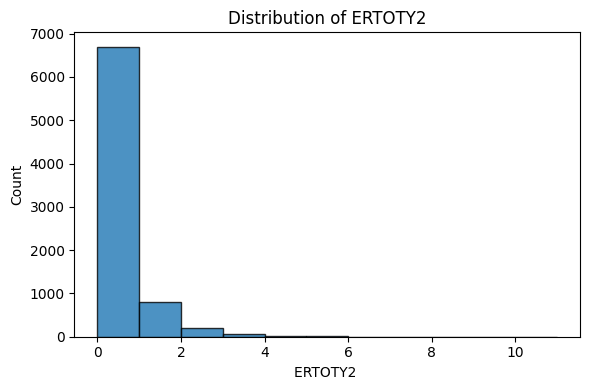

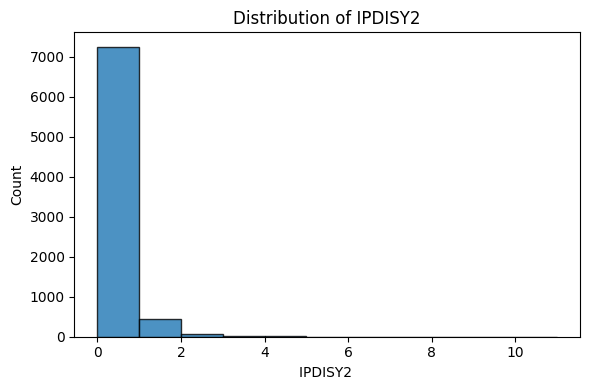

In [54]:
#Histogram for visit counts 
for col in ["ERTOTY2", "IPDISY2"]:
    if col in df_pre.columns:
        plt.figure(figsize=(6,4))
        data = df_pre[col]
        data.hist(bins=range(0,12), edgecolor="black", alpha=0.8)
        plt.xlabel(f"{col} ")
        plt.ylabel("Count")
        plt.title(f"Distribution of {col}")
        plt.tight_layout()
        plt.grid(False) 
        plt.show()


**Distribution of ED and inpatient visit counts (ERTOTY, IPDISY)**

- ED visits (ERTOTY1/2): The median and 75th percentile are both 0, meaning at least 75% of individuals had no ED visits within a year. The mean is only around 0.20, while the maximum reaches 12 (Year 1) and 22 (Year 2), indicating a small subgroup with frequent ED use.

- Inpatient discharges (IPDISY1/2): Similarly, the median and 75th percentile are 0, so most individuals had no inpatient stays in a given year. The mean is ~0.07–0.09, and the maximum is 4 (Year 1) and 5 (Year 2).

The histograms reinforce this pattern: counts are heavily concentrated at 0, with far fewer people having 1–2 events, and 3+ events forming a small high-use tail.

### 6） Payers share 

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pay_cols_y2 = [
    "TOTSLFY2",  # self/family
    "TOTPRVY2",  # private insurance
    "TOTMCRY2",  # Medicare
    "TOTMCDY2",  # Medicaid
    "TOTVAY2",   # VA/CHAMPVA
    "TOTTRIY2",  # TRICARE
    "TOTOFDY2",  # other federal
    "TOTSTLY2",  # state/local
    "TOTWCPY2",  # workers' comp
    "TOTOSRY2",  # other sources
]

pay_labels = {
    "TOTSLFY2": "Self / family",
    "TOTPRVY2": "Private",
    "TOTMCRY2": "Medicare",
    "TOTMCDY2": "Medicaid",
    "TOTVAY2":  "VA/CHAMPVA",
    "TOTTRIY2": "TRICARE",
    "TOTOFDY2": "Other federal",
    "TOTSTLY2": "State / local",
    "TOTWCPY2": "Workers' comp",
    "TOTOSRY2": "Other",
}


In [ ]:

pay_cols_y2 = [c for c in pay_cols_y2 if c in df_pre.columns]

tot_by_payer = df_pre[pay_cols_y2].sum()
tot_all = df_pre["TOTEXPY2"].sum()

share = (tot_by_payer / tot_all).sort_values(ascending=False)

labels = [pay_labels.get(c, c) for c in share.index]
values = share.values


Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.8.1_payer_level.png


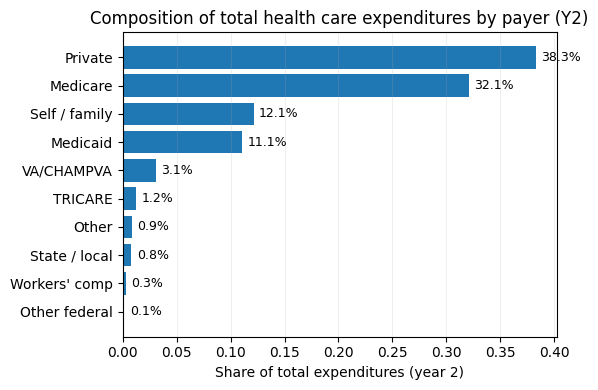

In [47]:
# share: Series, index = pay_cols_y2, values = share of total expenditures
labels = [pay_labels.get(c, c) for c in share.index]
values = share.values

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(labels, values)

ax.set_xlabel("Share of total expenditures (year 2)")
ax.set_title("Composition of total health care expenditures by payer (Y2)")
ax.grid(axis="x", alpha=0.2)
ax.invert_yaxis()

for bar, val in zip(bars, values):
    ax.text(
        bar.get_width() + 0.005,                      
        bar.get_y() + bar.get_height() / 2,         
        f"{val:.1%}",                                
        va="center",
        fontsize=9,
    )

fig.tight_layout()

out_path = FIGURES_DIR / "Figure_A.8.1_payer_level.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved figure to:", out_path)
plt.show()


For the overall sample, private insurance and Medicare are the dominant payment sources, together covering well over two-thirds of total expenditures. Out-of-pocket spending and Medicaid also represent important components, while other payers account for only a small share overall.



At the individual level, we examine how spending is distributed across payers for each person.
Because the number of payer categories is large, we focus on the four main sources in Year 2:

- Self / family (out-of-pocket): TOTSLFY2

- Private insurance: TOTPRVY2

- Medicare: TOTMCRY2

- Medicaid: TOTMCDY2

Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.8.2_individual_level.png


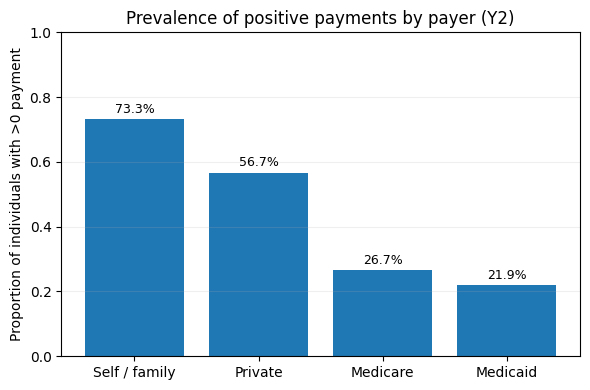

In [48]:


main_pay_cols = ["TOTSLFY2", "TOTPRVY2", "TOTMCRY2", "TOTMCDY2"]


has_share = {}
for col in main_pay_cols:
    s = df_pre[col].fillna(0)
    has_share[col] = (s > 0).mean()

main_pay_cols = [c for c in main_pay_cols if c in has_share]

labels = [pay_labels.get(c, c) for c in main_pay_cols]
values = [has_share[c] for c in main_pay_cols]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, values)

ax.set_ylabel("Proportion of individuals with >0 payment")
ax.set_title("Prevalence of positive payments by payer (Y2)")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.2)


for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

fig.tight_layout()

out_path = FIGURES_DIR / "Figure_A.8.2_individual_level.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved figure to:", out_path)
plt.show()


- Out-of-pocket spending has the broadest coverage: most individuals incur at least some self/family payments (e.g., deductibles and copayments).

- Private insurance also covers a large share of individuals. In contrast, Medicare and Medicaid are concentrated in specific groups (older adults and lower-income populations), so their overall prevalence in the full sample is lower.

Among individuals who actually made payments through self/family, private insurance, Medicare, or Medicaid (i.e., payer-specific spending > 0), what is the typical annual amount paid per person? And which payer tends to have higher per-person spending?

Saved figure to: /Users/wenxi/Desktop/TFM_25/results/figures/Figure_A.8.3_payments_amount.png


/var/folders/nr/rpw2sxkn3gqfcrlz5z0bcfw80000gp/T/ipykernel_58779/3685117161.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


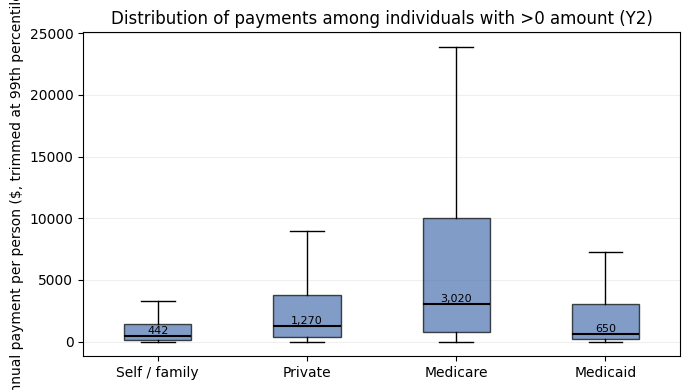

In [52]:


data = []
labels_box = []

for col in main_pay_cols:
    s = df_pre[col].dropna()
    s = s[s > 0]   
    if len(s) == 0:
        continue

    
    upper = s.quantile(0.99)
    s_clip = s.clip(upper=upper)

    data.append(s_clip.values)
    labels_box.append(pay_labels.get(col, col))

fig, ax = plt.subplots(figsize=(7, 4))
box = ax.boxplot(
    data,
    labels=labels_box,
    showfliers=False,
    patch_artist=True,
)

for patch in box["boxes"]:
    patch.set_facecolor("#4c72b0")
    patch.set_alpha(0.7)
for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

ax.set_ylabel("Annual payment per person ($, trimmed at 99th percentile)")
ax.set_title("Distribution of payments among individuals with >0 amount (Y2)")
ax.grid(axis="y", alpha=0.2)


medians = [np.median(d) for d in data]
for i, median_val in enumerate(medians, start=1):
    ax.text(
        i,
        median_val,
        f"{median_val:,.0f}",   
        ha="center",
        va="bottom",
        fontsize=8,
    )

fig.tight_layout()

out_path = FIGURES_DIR / "Figure_A.8.3_payments_amount.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved figure to:", out_path)
plt.show()



From a “who pays more” perspective, Medicare has the highest per-person amounts among those with any Medicare payments, followed by private insurance. Medicaid and out-of-pocket spending tend to have lower per-person amounts, but they have broad coverage across individuals.

* Medicare primarily covers adults aged 65+ and younger individuals with severe disability or chronic conditions, the fact that per-person Medicare payments are substantially higher than for other payers suggests that older and medically complex patients account for a large share of total spending.